In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

df = pd.read_csv('../data/creditcard.csv')

# ── Split by time period ──────────────────────────────────────────────────
day1 = df[df['Time'] <= 86400].copy()
day2 = df[df['Time'] >  86400].copy()

print(f"Day 1: {len(day1):,} transactions | Fraud: {day1['Class'].sum()}")
print(f"Day 2: {len(day2):,} transactions | Fraud: {day2['Class'].sum()}")

# ── Check if fraud patterns actually differ ───────────────────────────────
print("\n── Fraud rate by day ──")
print(f"Day 1 fraud rate: {day1['Class'].mean()*100:.3f}%")
print(f"Day 2 fraud rate: {day2['Class'].mean()*100:.3f}%")

print("\n── V14 mean by class and day ──")
for day, label in [(day1, 'Day1'), (day2, 'Day2')]:
    legit_v14 = day[day['Class']==0]['V14'].mean()
    fraud_v14 = day[day['Class']==1]['V14'].mean()
    print(f"{label} → Legit V14: {legit_v14:.3f} | Fraud V14: {fraud_v14:.3f} | Gap: {abs(legit_v14-fraud_v14):.3f}")

Day 1: 144,787 transactions | Fraud: 281
Day 2: 140,020 transactions | Fraud: 211

── Fraud rate by day ──
Day 1 fraud rate: 0.194%
Day 2 fraud rate: 0.151%

── V14 mean by class and day ──
Day1 → Legit V14: 0.042 | Fraud V14: -7.286 | Gap: 7.328
Day2 → Legit V14: -0.018 | Fraud V14: -6.553 | Gap: 6.535


In [3]:
# ── Helper: preprocess a dataframe ───────────────────────────────────────
def prepare(data):
    d = data.copy()
    scaler = StandardScaler()
    d['Amount_Scaled'] = scaler.fit_transform(d[['Amount']])
    d['Time_Scaled']   = scaler.fit_transform(d[['Time']])
    d.drop(columns=['Amount', 'Time'], inplace=True)
    X = d.drop(columns=['Class'])
    y = d['Class']
    return X, y

X_day1, y_day1 = prepare(day1)
X_day2, y_day2 = prepare(day2)

# ── Model 1: trained on Day 1 only, tested on Day 2 ──────────────────────
smote = SMOTE(random_state=42)
X_day1_res, y_day1_res = smote.fit_resample(X_day1, y_day1)

model_day1 = XGBClassifier(n_estimators=100, random_state=42,
                            eval_metric='logloss', verbosity=0)
model_day1.fit(X_day1_res, y_day1_res)

prob_drift = model_day1.predict_proba(X_day2)[:, 1]
pred_drift = (prob_drift >= 0.948).astype(int)

print("\n── Model trained on Day1, tested on Day2 (Drift Scenario) ──")
print(classification_report(y_day2, pred_drift,
      target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_day2, prob_drift):.4f}")


── Model trained on Day1, tested on Day2 (Drift Scenario) ──
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    139809
       Fraud       0.73      0.74      0.74       211

    accuracy                           1.00    140020
   macro avg       0.87      0.87      0.87    140020
weighted avg       1.00      1.00      1.00    140020

AUC-ROC: 0.9592


In [4]:
# ── Model 2: trained on full data, tested on Day 2 ───────────────────────
X_full, y_full = prepare(df)
X_train_f, _, y_train_f, _ = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)

X_train_res, y_train_res = smote.fit_resample(X_train_f, y_train_f)

model_full = XGBClassifier(n_estimators=100, random_state=42,
                            eval_metric='logloss', verbosity=0)
model_full.fit(X_train_res, y_train_res)

prob_full = model_full.predict_proba(X_day2)[:, 1]
pred_full = (prob_full >= 0.948).astype(int)

print("\n── Model trained on Full Data, tested on Day2 (Baseline) ──")
print(classification_report(y_day2, pred_full,
      target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_day2, prob_full):.4f}")


── Model trained on Full Data, tested on Day2 (Baseline) ──
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    139809
       Fraud       0.98      0.96      0.97       211

    accuracy                           1.00    140020
   macro avg       0.99      0.98      0.99    140020
weighted avg       1.00      1.00      1.00    140020

AUC-ROC: 0.9979


In [5]:
# ── Side by side comparison ───────────────────────────────────────────────
from sklearn.metrics import recall_score, precision_score

comparison = pd.DataFrame({
    'Scenario': ['Day1-only model on Day2', 'Full-data model on Day2'],
    'Recall':   [recall_score(y_day2, pred_drift),
                 recall_score(y_day2, pred_full)],
    'Precision':[precision_score(y_day2, pred_drift, zero_division=0),
                 precision_score(y_day2, pred_full, zero_division=0)],
    'AUC-ROC':  [roc_auc_score(y_day2, prob_drift),
                 roc_auc_score(y_day2, prob_full)]
})
print("\n── Concept Drift Impact Summary ──")
print(comparison.round(4))


── Concept Drift Impact Summary ──
                  Scenario  Recall  Precision  AUC-ROC
0  Day1-only model on Day2  0.7441     0.7336   0.9592
1  Full-data model on Day2  0.9621     0.9807   0.9979


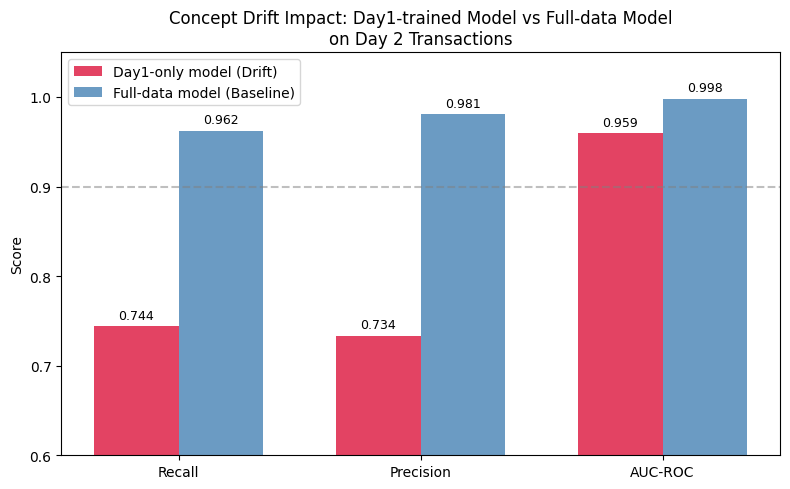


── Key Finding ──
Recall dropped by:    21.8% due to concept drift
Precision dropped by: 24.7% due to concept drift
AUC-ROC dropped by:   0.0387 due to concept drift

Conclusion: Model retraining on recent data is critical for
maintaining fraud detection performance in production.


In [6]:
import matplotlib.pyplot as plt
import numpy as np

metrics      = ['Recall', 'Precision', 'AUC-ROC']
drift_scores = [0.7441, 0.7336, 0.9592]
full_scores  = [0.9621, 0.9807, 0.9979]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, drift_scores, width,
               label='Day1-only model (Drift)', color='crimson',   alpha=0.8)
bars2 = ax.bar(x + width/2, full_scores,  width,
               label='Full-data model (Baseline)', color='steelblue', alpha=0.8)

# Annotate values on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylim(0.6, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Concept Drift Impact: Day1-trained Model vs Full-data Model\non Day 2 Transactions')
ax.legend()
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='0.9 reference line')

plt.tight_layout()
plt.savefig('concept_drift_comparison.png', dpi=150)
plt.show()

print("\n── Key Finding ──")
print(f"Recall dropped by:    {(0.9621 - 0.7441)*100:.1f}% due to concept drift")
print(f"Precision dropped by: {(0.9807 - 0.7336)*100:.1f}% due to concept drift")
print(f"AUC-ROC dropped by:   {(0.9979 - 0.9592):.4f} due to concept drift")
print("\nConclusion: Model retraining on recent data is critical for")
print("maintaining fraud detection performance in production.")